In [23]:
import pandas as pd

df = pd.read_csv("../data/supplier_risk_data.csv")
df.head()

,supplier_id;region;industry;on_time_delivery_rate;defect_rate;avg_lead_time_days;financial_score;past_incidents;high_risk
0,S0001;Africa;Retail;0.99;0.07;37;816;0;0
1,S0002;South America;Manufacturing;0.76;0.05;37...
2,S0003;Asia;Retail;0.93;0.06;65;464;8;1
3,S0004;South America;IT;0.92;0.06;55;721;2;0
4,S0005;South America;Manufacturing;0.66;0.17;47...


In [25]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/supplier_risk_data.csv")

# Quick overview
print(df.shape)
print(df.info())
df.describe()

(100, 1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype 
---  ------                                                                                                                     --------------  ----- 
 0   supplier_id;region;industry;on_time_delivery_rate;defect_rate;avg_lead_time_days;financial_score;past_incidents;high_risk  100 non-null    object
dtypes: object(1)
memory usage: 932.0+ bytes
None


,supplier_id;region;industry;on_time_delivery_rate;defect_rate;avg_lead_time_days;financial_score;past_incidents;high_risk
count,100
unique,100
top,S0001;Africa;Retail;0.99;0.07;37;816;0;0
freq,1


In [29]:
print(df.columns)

Index(['supplier_id;region;industry;on_time_delivery_rate;defect_rate;avg_lead_time_days;financial_score;past_incidents;high_risk'], dtype='object')


In [40]:
df.columns = df.columns.str.strip()

In [47]:
import seaborn as sns

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load CSV with semicolon separator
df = pd.read_csv("../data/supplier_risk_data.csv", sep=';')

# Check columns
print(df.columns)

Index(['supplier_id', 'region', 'industry', 'on_time_delivery_rate',
       'defect_rate', 'avg_lead_time_days', 'financial_score',
       'past_incidents', 'high_risk'],
      dtype='object')


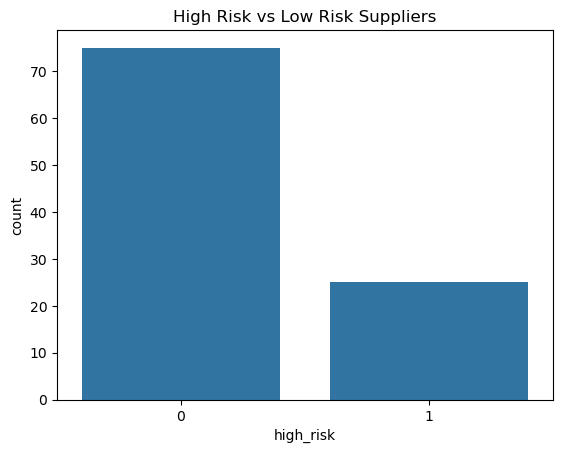

In [55]:
sns.countplot(x="high_risk", data=df)
plt.title("High Risk vs Low Risk Suppliers")
plt.show()

In [57]:
df_encoded = pd.get_dummies(df, columns=["region", "industry"], drop_first=True)

X = df_encoded.drop("high_risk", axis=1)
y = df_encoded["high_risk"]

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

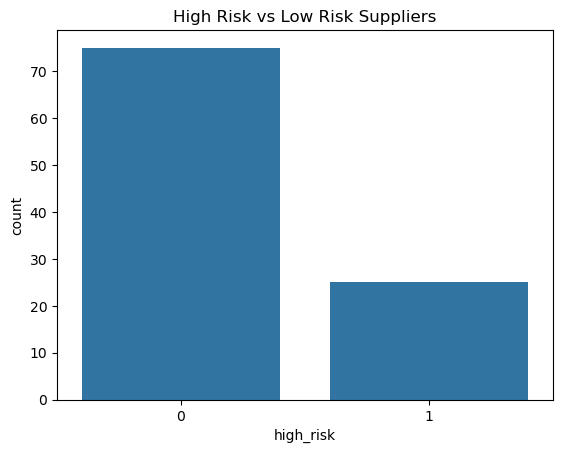

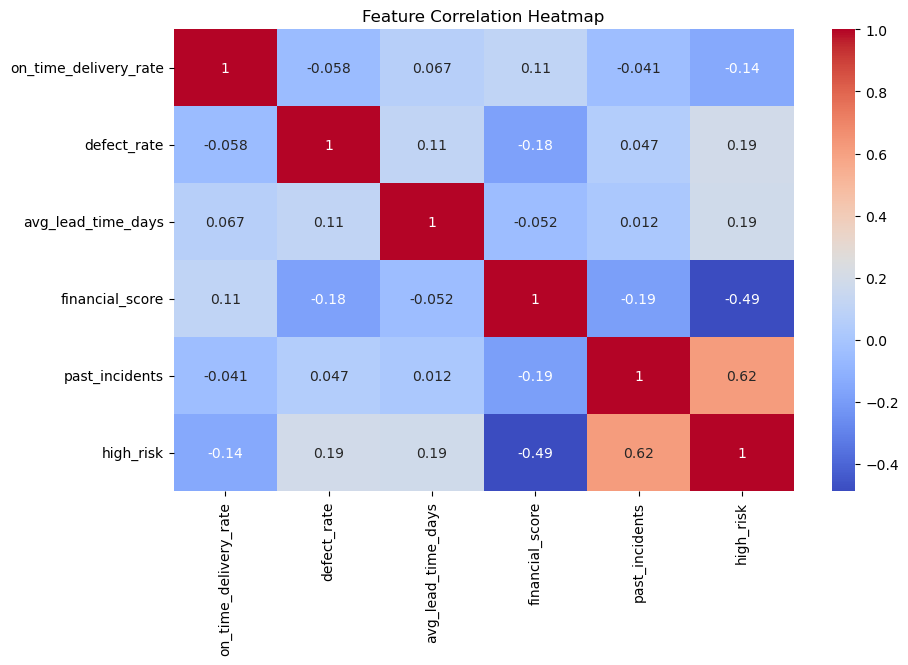

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load CSV correctly
df = pd.read_csv("../data/supplier_risk_data.csv", sep=';')

# Countplot (categorical column)
sns.countplot(x="high_risk", data=df)
plt.title("High Risk vs Low Risk Suppliers")
plt.show()

# Correlation heatmap (numeric columns only)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

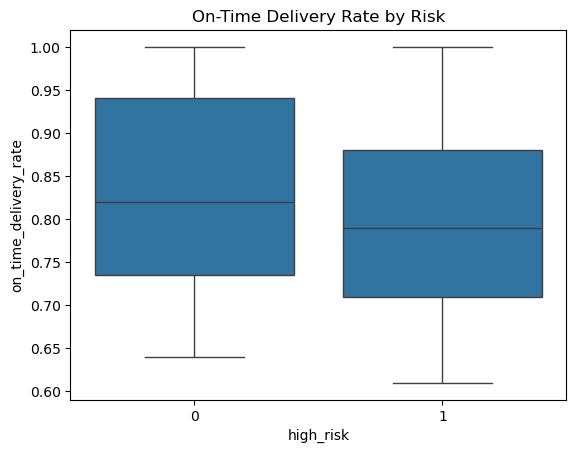

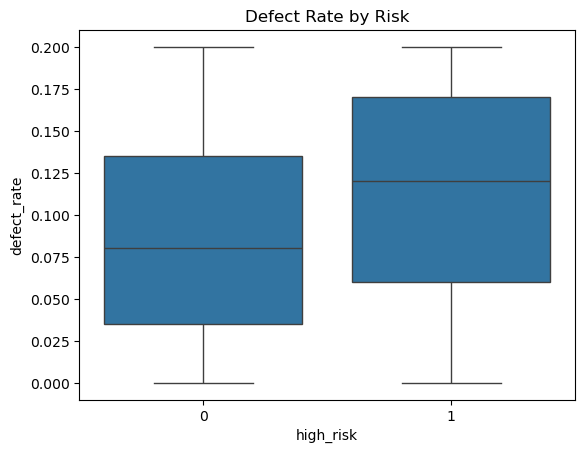

In [62]:
sns.boxplot(x="high_risk", y="on_time_delivery_rate", data=df)
plt.title("On-Time Delivery Rate by Risk")
plt.show()

sns.boxplot(x="high_risk", y="defect_rate", data=df)
plt.title("Defect Rate by Risk")
plt.show()

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [69]:
X = df.select_dtypes(include='number').drop('high_risk', axis=1)  # features
y = df['high_risk']  # target

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

Logistic Regression ROC-AUC: 1.0
Random Forest ROC-AUC: 0.9791666666666667
Logistic Regression Confusion Matrix:
 [[12  0]
 [ 0  8]]
Random Forest Confusion Matrix:
 [[12  0]
 [ 2  6]]


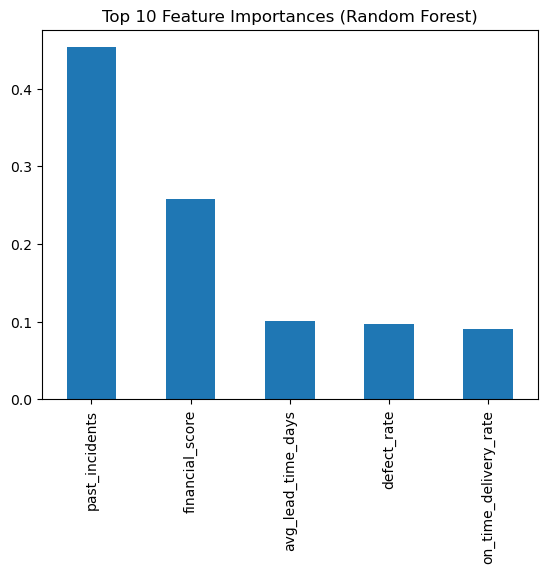

In [71]:
# ROC-AUC
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# Confusion Matrix
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()